In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, AdaBoostRegressor, RandomForestRegressor
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load processed dataset

In [4]:
X_train = pd.read_csv('FIFA_Binary_Cleaned_Final_Train.csv')
X_test = pd.read_csv('FIFA_Binary_Cleaned_Final_Test.csv')


In [5]:
target_column = 'wage_eur'
y_train = X_train[target_column]
X_train = X_train.drop(columns=[target_column])

y_test = X_test[target_column]
X_test = X_test.drop(columns=[target_column])

# Anomaly Detection methods

In [6]:
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train)
X_train_pca_df = pd.DataFrame(X_train_pca, columns=['PC1', 'PC2'])

In [7]:
iso = IsolationForest(contamination=0.05, random_state=42).fit_predict(X_train_pca_df)

In [8]:
knn_dist, _ = NearestNeighbors(n_neighbors=5).fit(X_train_pca_df).kneighbors(X_train_pca_df)
knn_anoms = knn_dist[:, -1] > np.percentile(knn_dist[:, -1], 95)

In [9]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit_predict(X_train_pca_df)

In [10]:
total_anomalies = (iso == -1).astype(int) + knn_anoms.astype(int) + (lof == -1).astype(int)
mask = total_anomalies < 2

In [11]:
X_train_refined = X_train[mask].reset_index(drop=True)
y_train_refined = y_train[mask].reset_index(drop=True)

print(f"Refined Data: {len(X_train_refined)} players remain for Wage Analysis.")

Refined Data: 13990 players remain for Wage Analysis.


# Visualising anomalies

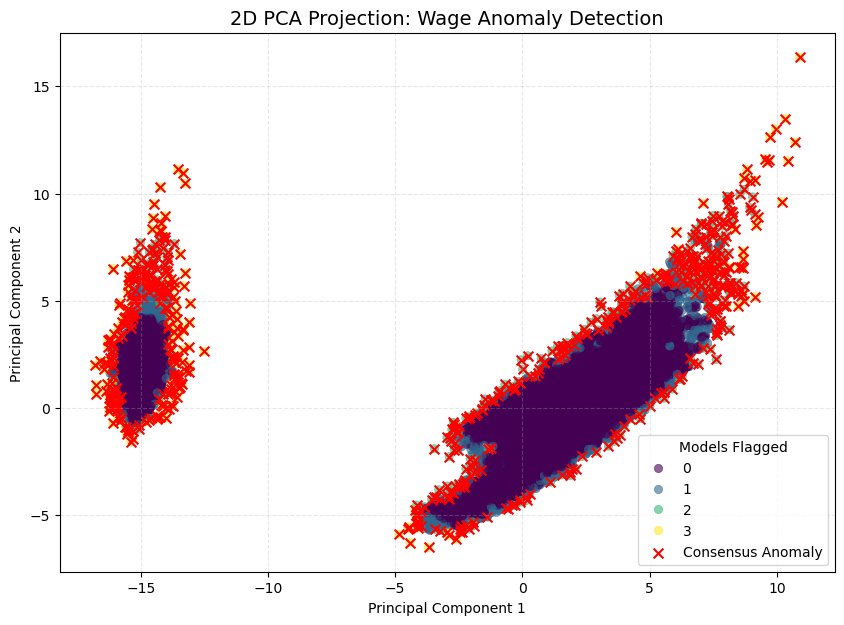

In [13]:
plt.figure(figsize=(10, 7))

sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], 
                hue=total_anomalies, 
                palette='viridis', 
                alpha=0.6, 
                edgecolor=None)

anomalies_idx = np.where(total_anomalies >= 2)
plt.scatter(X_train_pca[anomalies_idx, 0], X_train_pca[anomalies_idx, 1], 
            color='red', label='Consensus Anomaly', s=50, marker='x')

plt.title('2D PCA Projection: Wage Anomaly Detection', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Models Flagged')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

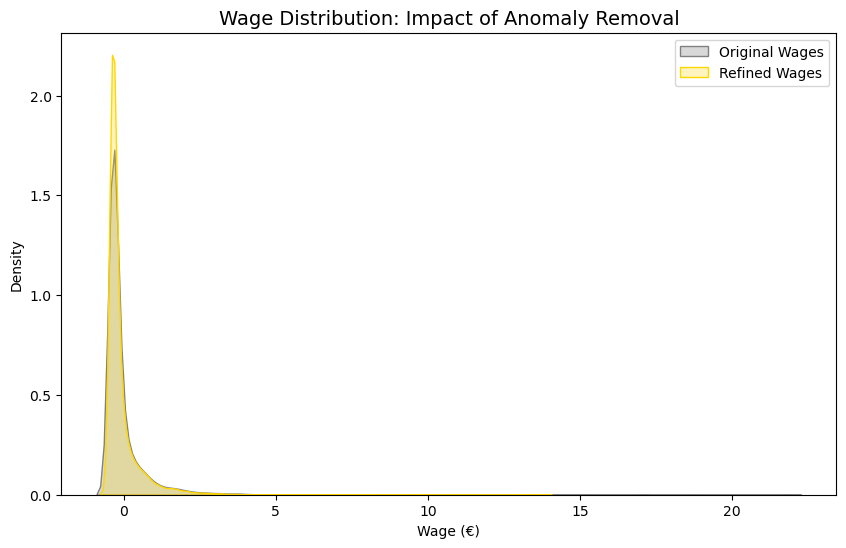

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_train, label='Original Wages', fill=True, color="gray", alpha=0.3)
sns.kdeplot(y_train_refined, label='Refined Wages', fill=True, color="gold")
plt.title('Wage Distribution: Impact of Anomaly Removal', fontsize=14)
plt.xlabel('Wage (€)')
plt.legend()
plt.show()

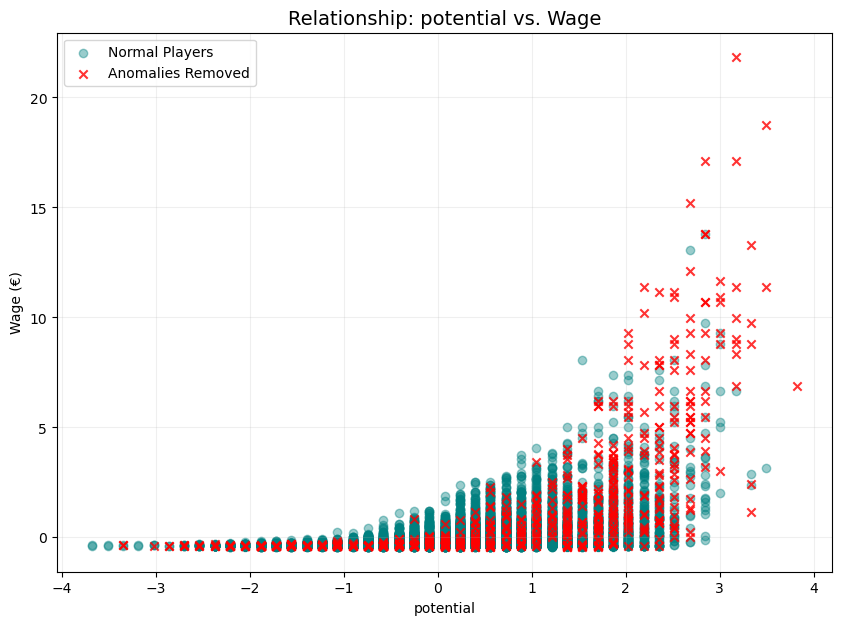

In [14]:

top_feature = 'potential' 

plt.figure(figsize=(10, 7))

plt.scatter(X_train[mask][top_feature], y_train_refined, 
            c='teal', alpha=0.4, label='Normal Players')

plt.scatter(X_train[~mask][top_feature], y_train[~mask], 
            c='red', alpha=0.8, marker='x', label='Anomalies Removed')

plt.title(f'Relationship: {top_feature} vs. Wage', fontsize=14)
plt.xlabel(top_feature)
plt.ylabel('Wage (€)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Recursive Feature Elimination (RFE)

In [15]:

X_train_iter = X_train_refined.copy()
X_test_iter = X_test.copy()
remaining_features = X_train_iter.columns.tolist()

best_r2 = 0
best_features_list = []

print(f"{'Features':<10} | {'R2 Score':<10} | {'Removed Feature'}")
print("-" * 55)

while len(remaining_features) > 1:
    model = AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=12, random_state=42),
        n_estimators=50, random_state=42
    )
    model.fit(X_train_iter, y_train_refined)
    y_pred = model.predict(X_test_iter)
    r2 = r2_score(y_test, y_pred)
    
    if r2 > best_r2:
        best_r2 = r2
        best_features_list = remaining_features.copy()

    importances = model.feature_importances_
    removed_feature = remaining_features[np.argmin(importances)]
    
    print(f"{len(remaining_features):<10} | {r2:<10.4f} | {removed_feature}")
    remaining_features.remove(removed_feature)
    X_train_iter = X_train_iter[remaining_features]
    X_test_iter = X_test_iter[remaining_features]

print("\n ✅ Wage Optimization Finished!")
print(f" Best R2 Score: {best_r2:.4f}")
print(f" Final Feature Count: {len(best_features_list)}")

Features   | R2 Score   | Removed Feature
-------------------------------------------------------
75         | 0.7908     | num_positions
74         | 0.7815     | gk_speed
73         | 0.8097     | gk_handling
72         | 0.7779     | gk_kicking
71         | 0.7844     | gk_positioning
70         | 0.7790     | gk_reflexes
69         | 0.7833     | gk_diving
68         | 0.7996     | loaned_from
67         | 0.7905     | skill_moves
66         | 0.7797     | overall_binary
65         | 0.7930     | player_tags_count
64         | 0.7981     | body_type
63         | 0.7905     | preferred_foot_Right
62         | 0.7892     | weak_foot
61         | 0.7695     | passing
60         | 0.7891     | dribbling
59         | 0.7910     | nation_jersey_number
58         | 0.7843     | work_rate
57         | 0.7915     | joined_month
56         | 0.7861     | player_traits_count
55         | 0.7911     | contract_valid_until
54         | 0.7972     | nation_position
53         | 0.7914     | pace

# Model comparaison before anomaly detection and after

In [18]:

baseline_reg = AdaBoostRegressor(random_state=42)
baseline_reg.fit(X_train, y_train)
baseline_r2 = r2_score(y_test, baseline_reg.predict(X_test))

print("\n--- FINAL REGRESSION SUMMARY ---")
print(f"The Model R2 before anomaly detection: {baseline_r2:.16f}")
print(f"After Removal of anomalies & Selection: {best_r2:.4f}")
print(f"Total Features used: {len(best_features_list)}")


--- FINAL REGRESSION SUMMARY ---
The Model R2 before anomaly detection: 0.2999541261918143
After Removal of anomalies & Selection: 0.8280
Total Features used: 20


# Model comparaison on refined dataset to identify better R2 square

--- Wage Regression: Model Performance Comparison ---

AdaBoost Results:
R2 Score: 0.8072
Mean Absolute Error: €0.18

Random Forest Results:
R2 Score: 0.7999
Mean Absolute Error: €0.17


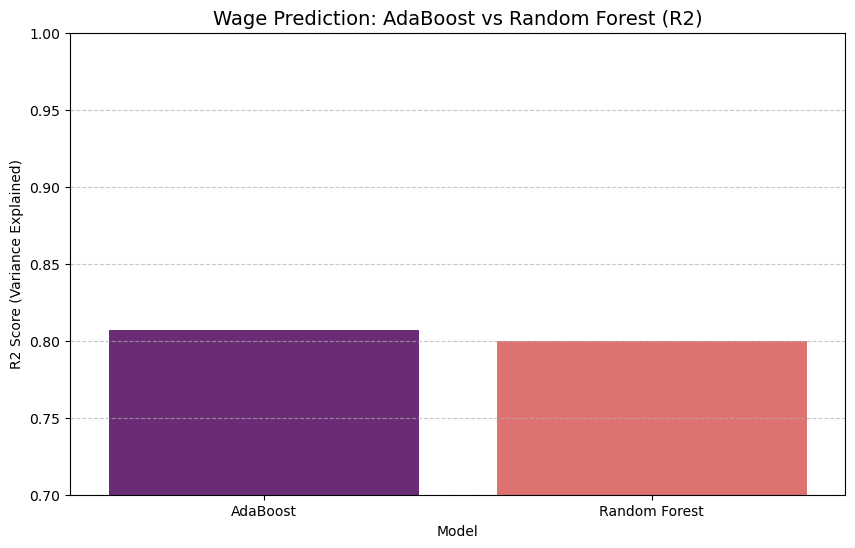

In [22]:

reg_models = {
    "AdaBoost": AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=12, random_state=42),
        n_estimators=100,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, 
        max_depth=15, 
        random_state=42
    )
}

results = []

print("--- Wage Regression: Model Performance Comparison ---")

for name, model in reg_models.items():
 
    model.fit(X_train_refined[best_features_list], y_train_refined)
    
    y_pred = model.predict(X_test[best_features_list])
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    results.append({
        "Model": name,
        "R2 Score": r2,
        "MAE (€)": mae,
        "RMSE (€)": rmse
    })
    
    print(f"\n{name} Results:")
    print(f"R2 Score: {r2:.4f}")
    print(f"Mean Absolute Error: €{mae:,.2f}")

comparison_df = pd.DataFrame(results).set_index("Model")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=comparison_df.reset_index(), 
    x='Model', 
    y='R2 Score', 
    hue='Model',       
    palette='magma', 
    legend=False       
)

plt.title('Wage Prediction: AdaBoost vs Random Forest (R2)', fontsize=14)

plt.ylim(0.7, 1.0) 
plt.ylabel('R2 Score (Variance Explained)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

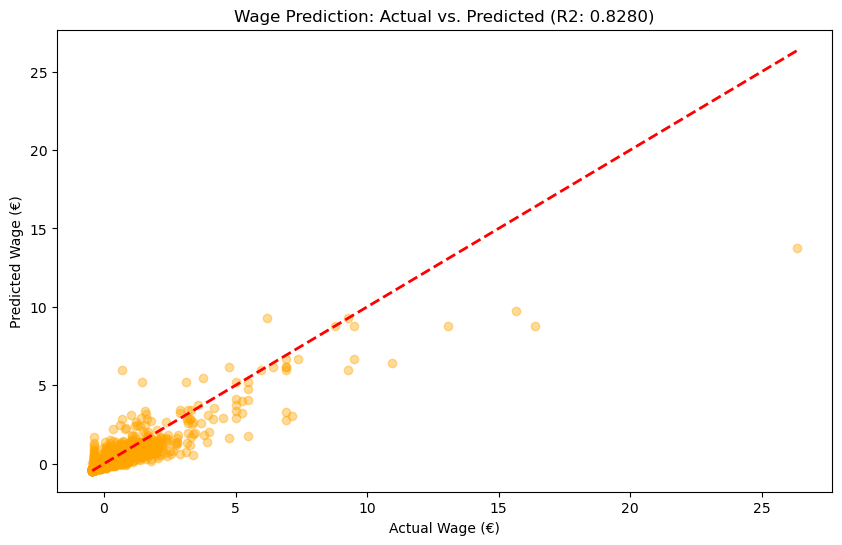

In [19]:
best_model_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=12, random_state=42),
    n_estimators=100, random_state=42
).fit(X_train_refined[best_features_list], y_train_refined)

y_pred_final = best_model_reg.predict(X_test[best_features_list])
residuals = y_test - y_pred_final


plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_final, alpha=0.4, color='orange', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Wage Prediction: Actual vs. Predicted (R2: {best_r2:.4f})')
plt.xlabel('Actual Wage (€)')
plt.ylabel('Predicted Wage (€)')
plt.show()

In [23]:
print("\n" + "="*50)
print(" ✅ Optimization Finished!")
print(f" Best R2 Score: {comparison_df.loc['AdaBoost', 'R2 Score']:.4f}")
print(f" Final Feature Count: {len(best_features_list)}")
print("="*50)


 ✅ Optimization Finished!
 Best R2 Score: 0.8072
 Final Feature Count: 20


# Feature importance and shap based on best model R2 sqaure

Calculating SHAP for Wages (Using RF for Speed)...


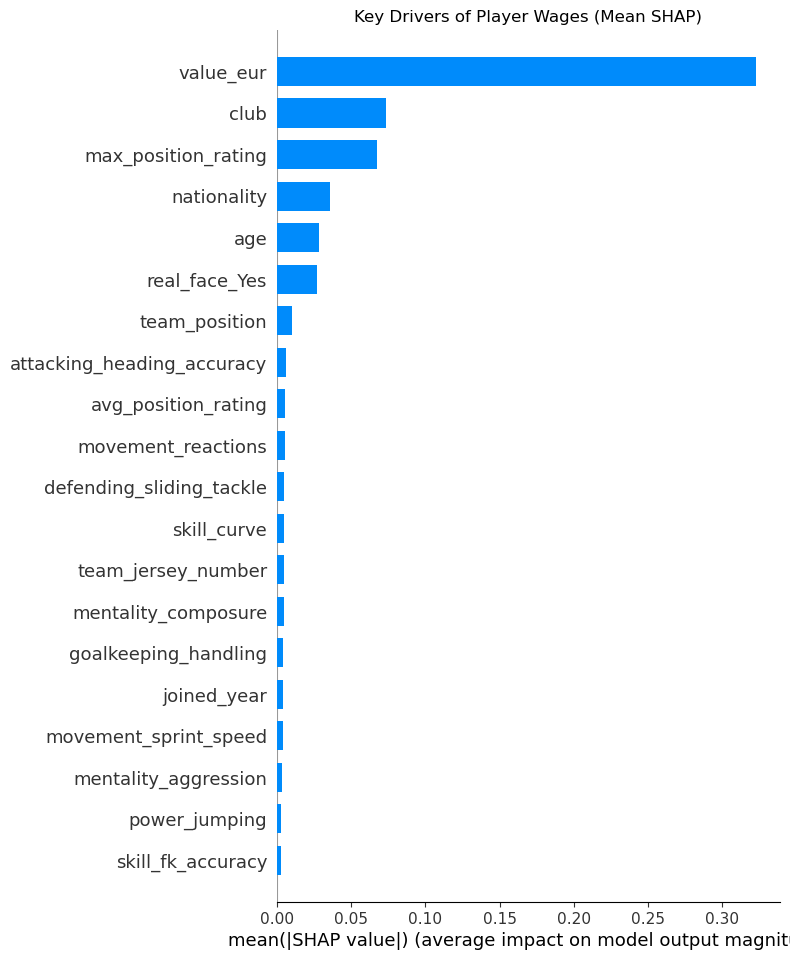

In [24]:

print("Calculating SHAP for Wages (Using RF for Speed)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(
    X_train_refined[best_features_list], y_train_refined
)

X_test_subset = X_test[best_features_list]
explainer = shap.TreeExplainer(rf_model)
target_shap = explainer.shap_values(X_test_subset)

plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="bar", show=False)
plt.title("Key Drivers of Player Wages (Mean SHAP)")
plt.show()

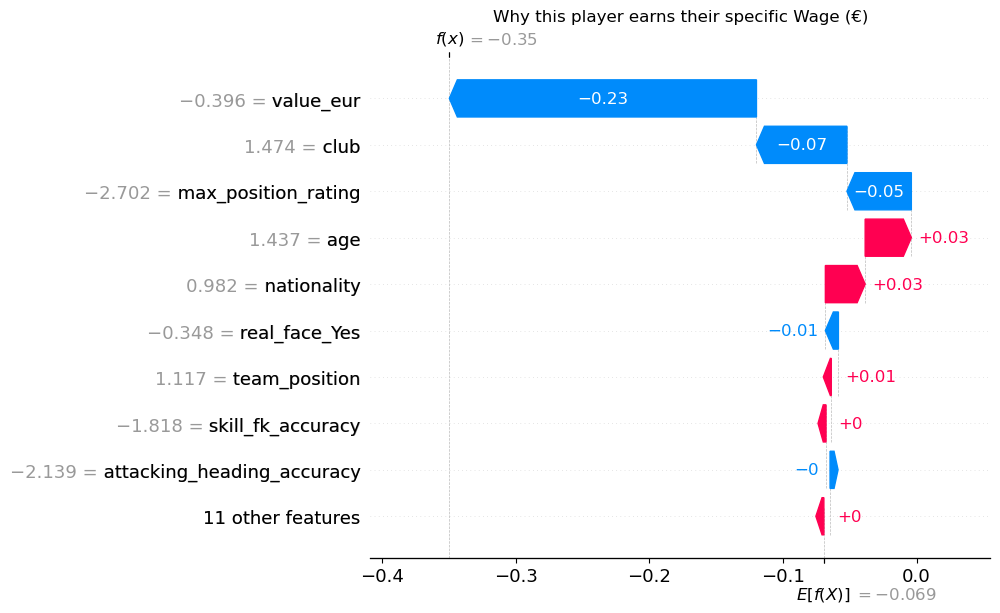

In [25]:
try:
    base_val = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    exp = shap.Explanation(values=target_shap[0], base_values=base_val, 
                           data=X_test_subset.iloc[0], feature_names=best_features_list)
    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(exp, show=False)
    plt.title("Why this player earns their specific Wage (€)")
    plt.show()
except Exception as e:
    print(f"Waterfall failed: {e}")

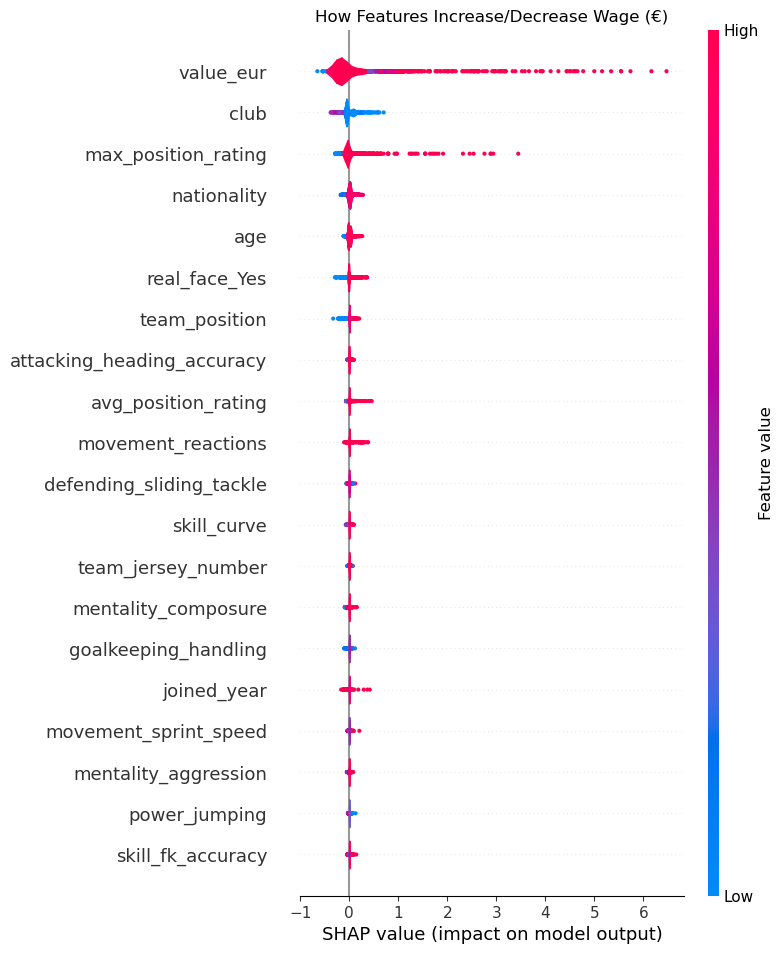

In [26]:
plt.figure(figsize=(10, 6))
shap.summary_plot(target_shap, X_test_subset, plot_type="violin", show=False)
plt.title("How Features Increase/Decrease Wage (€)")
plt.show()